In [2]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

Data Cleaning

In [3]:
# Fix TotalCharges

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [4]:
# Drop irrelevant columns
df.drop('customerID', axis=1, inplace=True)

In [5]:
# Convert target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Exploratory Data Analysis (EDA)

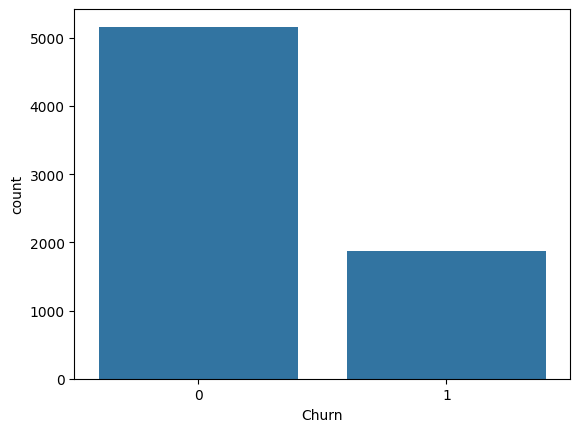

In [6]:
# Churn distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

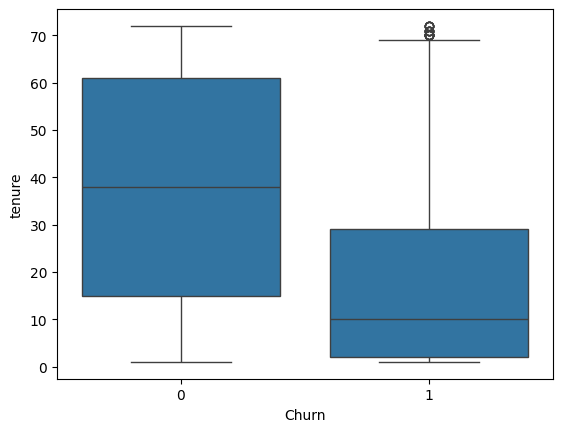

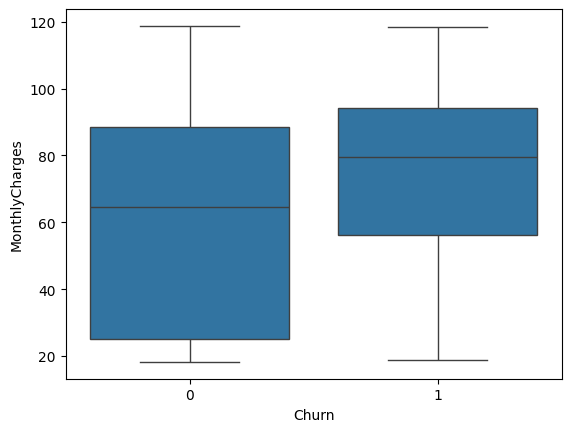

In [7]:
# Numerical analysis
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

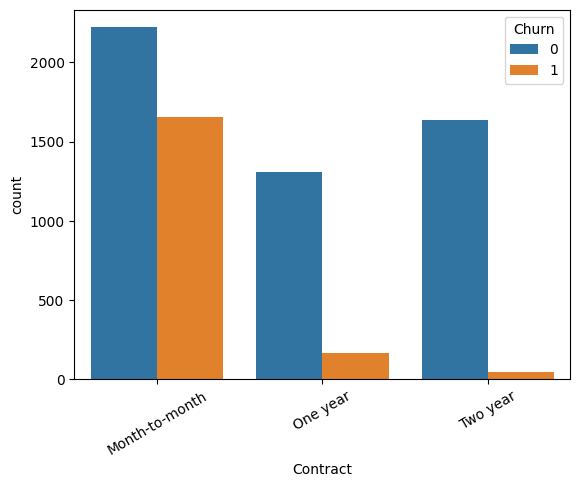

In [8]:
# Categorical analysis
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

Feature Engineering

In [9]:
# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling (Important for Logistic Regression)

In [11]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Models

In [12]:

# Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [13]:
#  Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
# XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Evaluate Models

In [15]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

def evaluate(model, X_test, y_test, scaled=False):
    if scaled:
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]
    
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("-"*30)

print("Logistic Regression")
evaluate(log_model, X_test_scaled, y_test, scaled=True)

print("Random Forest")
evaluate(rf_model, X_test, y_test)

print("XGBoost")
evaluate(xgb_model, X_test, y_test)

Logistic Regression
Accuracy: 0.7874911158493249
Recall: 0.516042780748663
ROC-AUC: 0.8319235288940887
------------------------------
Random Forest
Accuracy: 0.7853589196872779
Recall: 0.47058823529411764
ROC-AUC: 0.8146616210507789
------------------------------
XGBoost
Accuracy: 0.7739872068230277
Recall: 0.49732620320855614
ROC-AUC: 0.8108152880090697
------------------------------


Feature Importance

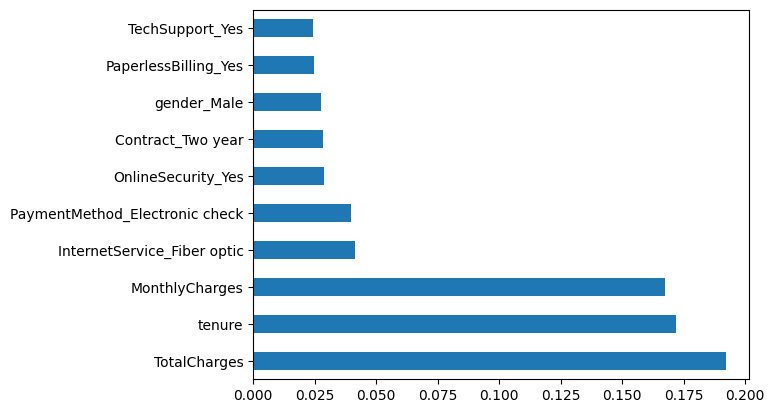

In [16]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.show()

Improve Model

In [21]:
import numpy as np
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),  # ✅ FIX: convert to numpy array
    y=y_train
)

print(weights)

[0.68099274 1.8812709 ]


In [22]:
df.to_csv("cleaned_churn_data.csv", index=False)